In [48]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [49]:
#Importing Data Sets
df_ask = pd.read_csv("GBPNOK_5 Mins_Ask_2025.08.01_2025.09.30.csv")
df_bid = pd.read_csv("GBPNOK_5 Mins_Bid_2025.08.01_2025.09.30.csv")

In [50]:
#Combine the two time-series for Ask & Bid into one Pandas DataFrame
df = df_bid.merge(df_ask, on='Time (UTC)', how='outer')
df.columns = ['Local time', 'Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
              'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask'] 

In [51]:
#Feature and Target Selection
features = df[['Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
               'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask']]
target = df[['High_Bid', 'Low_Ask']].shift(-1)
features = features[:-1]
target = target[:-1]

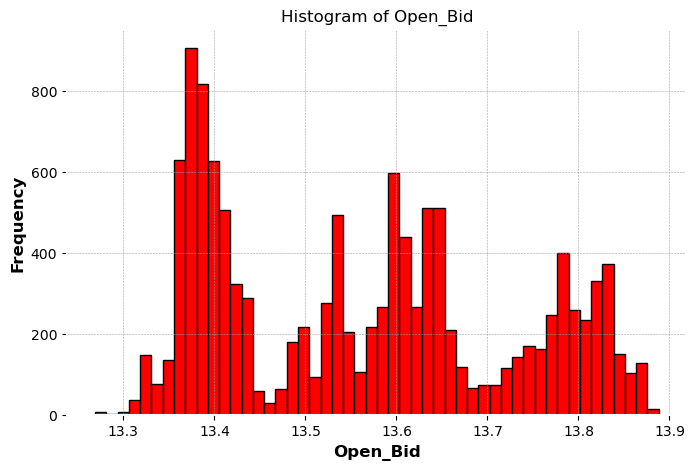

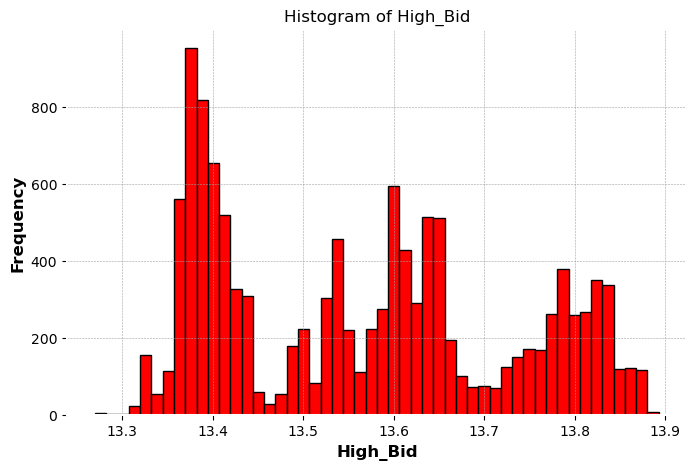

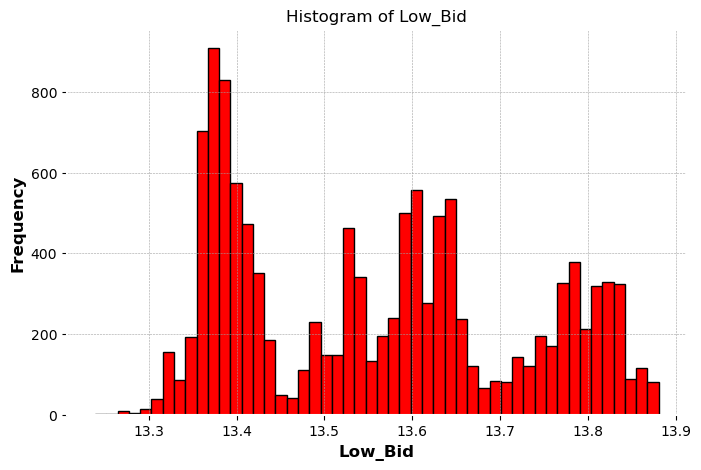

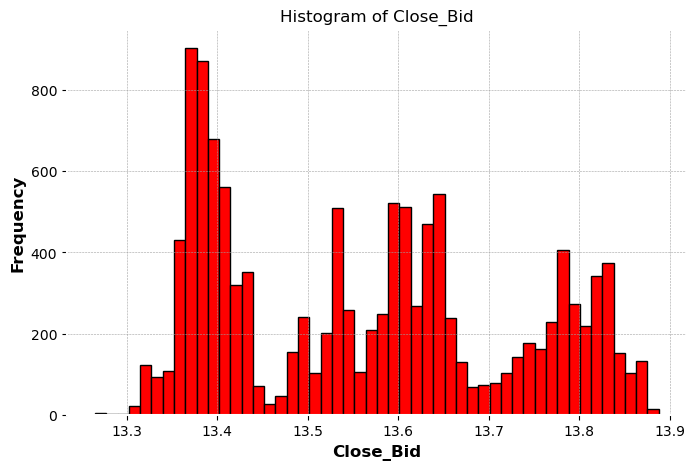

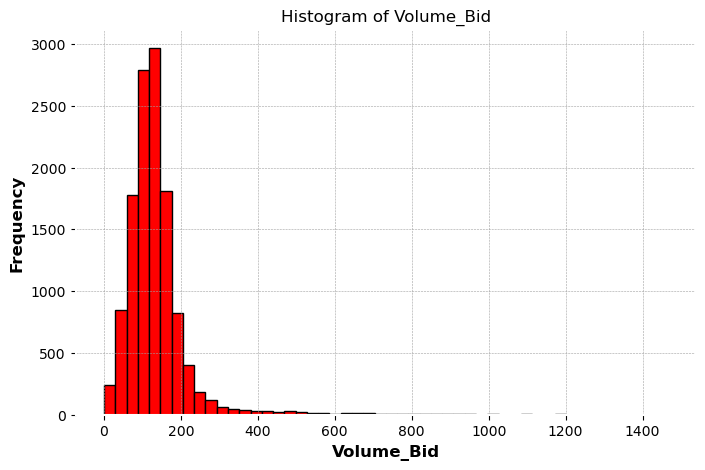

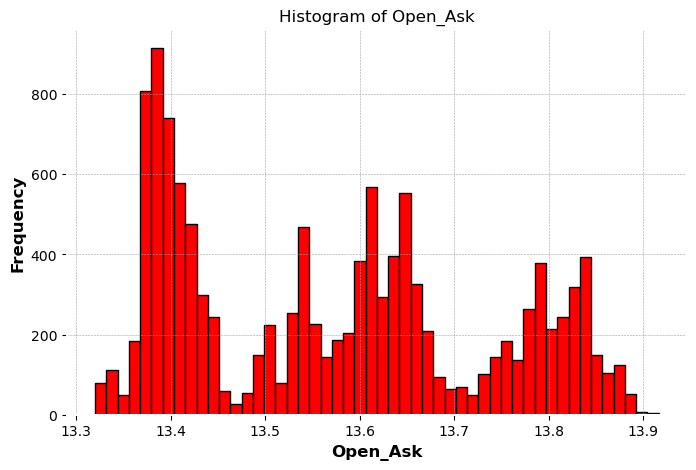

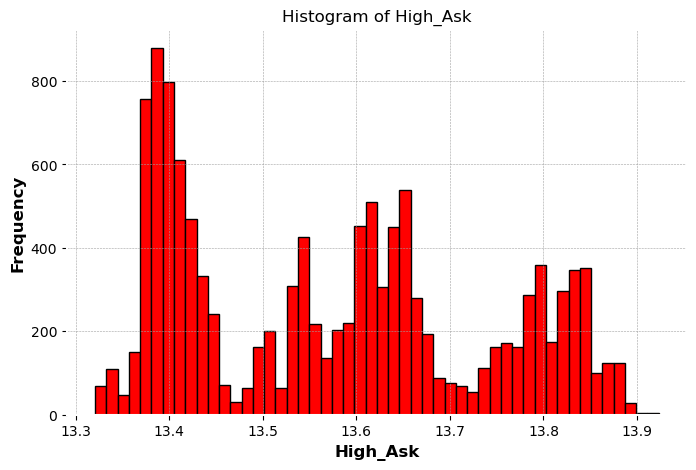

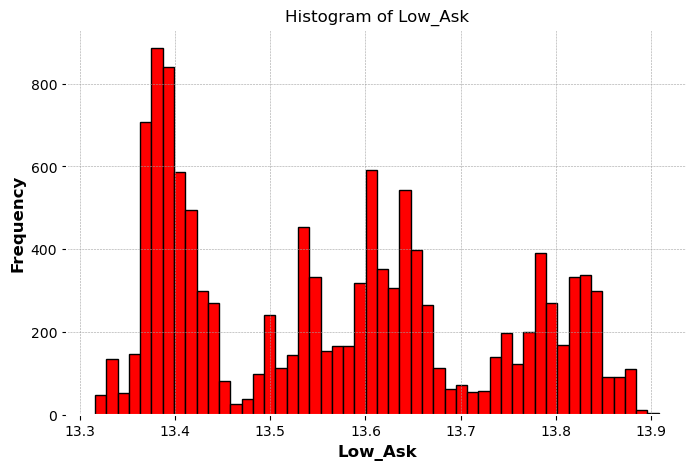

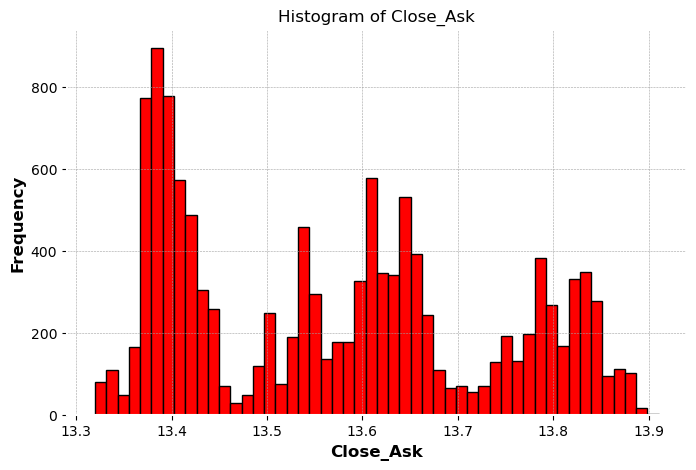

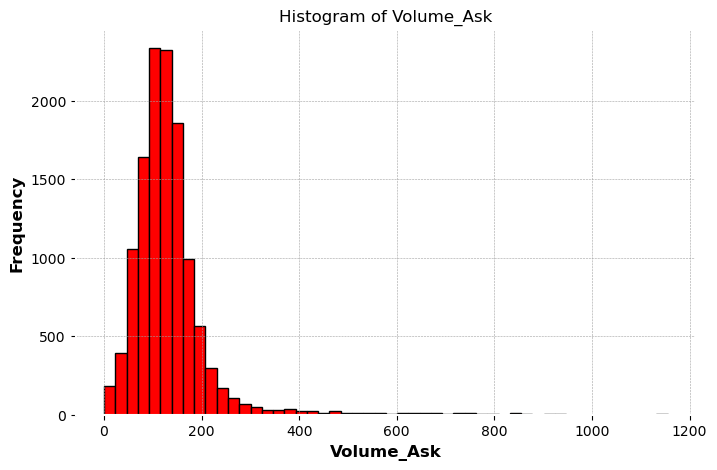

In [52]:
for feature in features:
    plt.figure(figsize=(8, 5))
    plt.hist(features[feature], bins=50, color='Red', edgecolor='black')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

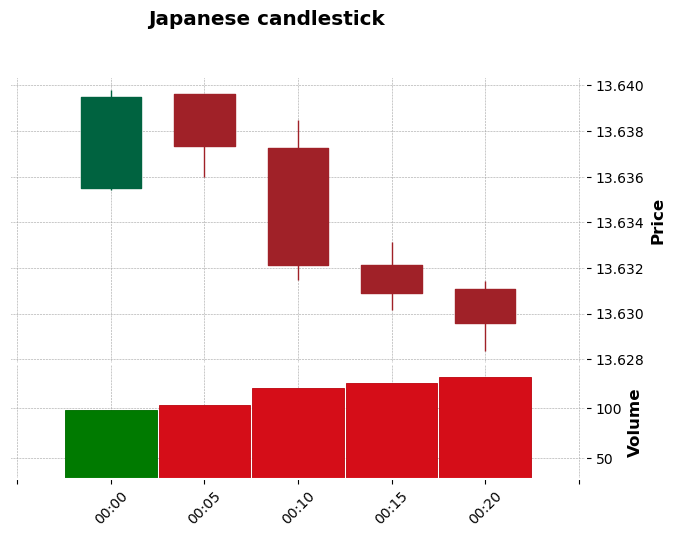

In [53]:
#Plot graphs and histograms
import mplfinance as mpf

df_candle = df.copy()
df_candle['Local time'] = pd.to_datetime(df_candle['Local time']) 
df_candle.set_index('Local time', inplace=True)
df_candle.rename(columns={'Open_Bid': 'Open','High_Bid': 'High','Low_Bid': 'Low','Close_Bid': 'Close','Volume_Bid': 'Volume'}, inplace=True)
mpf.plot(df_candle.iloc[0:5], type = 'candle', style = 'charles', title = 'Japanese candlestick', volume = True)

In [54]:
# : Normalize Features if necessary.
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# Reshape for LSTM: [samples, timesteps, features]
X = np.reshape(scaled_features, (scaled_features.shape[0], 1, scaled_features.shape[1]))
y = target.to_numpy()

In [55]:
# Time-aware train-test split 90/10
split_index = int(len(X) * 0.9)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [56]:
# Build LSTM Model
model_lstm = Sequential([
    LSTM(64, input_shape=(1, 10), return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(2)  
])

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.summary()

C:\Users\_msi_\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          19,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,490 (91.76 KB)

 Trainable params: 23,490 (91.76 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Training Epochs = 11, Batch Size = 50 Validation size = 20% and patience = 6
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_lstm.h5', save_best_only=True)
history_lstm = model_lstm.fit(X_train, y_train, epochs=11, batch_size=50, validation_split=0.2, callbacks=[early_stop, checkpoint], verbose=1)

Epoch 1/11
164/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 123.7314

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 118.3670 - val_loss: 49.4993
Epoch 2/11
173/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5940

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.5218 - val_loss: 11.5906
Epoch 3/11
168/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7888

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7703 - val_loss: 2.8126
Epoch 4/11
170/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1858

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1825 - val_loss: 1.7680
Epoch 5/11
173/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0409

...

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8510 - val_loss: 0.6283
Epoch 7/11
174/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8095

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8088 - val_loss: 0.2769
Epoch 8/11
164/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7290

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7257 - val_loss: 0.1580
Epoch 9/11
171/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6388

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6375 - val_loss: 0.0748
Epoch 10/11
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5178

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5176 - val_loss: 0.0340
Epoch 11/11
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4337 - val_loss: 0.0394


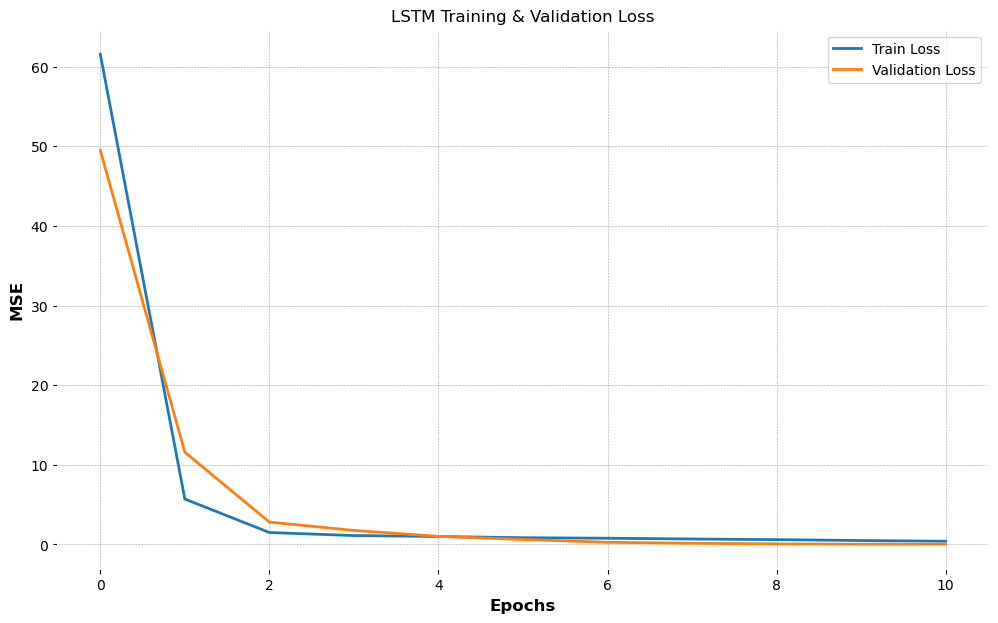

In [58]:
# Training Loss Plot
plt.figure(figsize=(12, 7))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
#  Evaluate on Test Set (MSE and MAE)
predictions_lstm = model_lstm.predict(X_test)
mse_lstm = mean_squared_error(y_test, predictions_lstm)
mae_lstm = mean_absolute_error(y_test, predictions_lstm)

print(f"LSTM Test MSE: {mse_lstm:.6f}")
print(f"LSTM Test MAE: {mae_lstm:.6f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSTM Test MSE: 0.023706
LSTM Test MAE: 0.103295


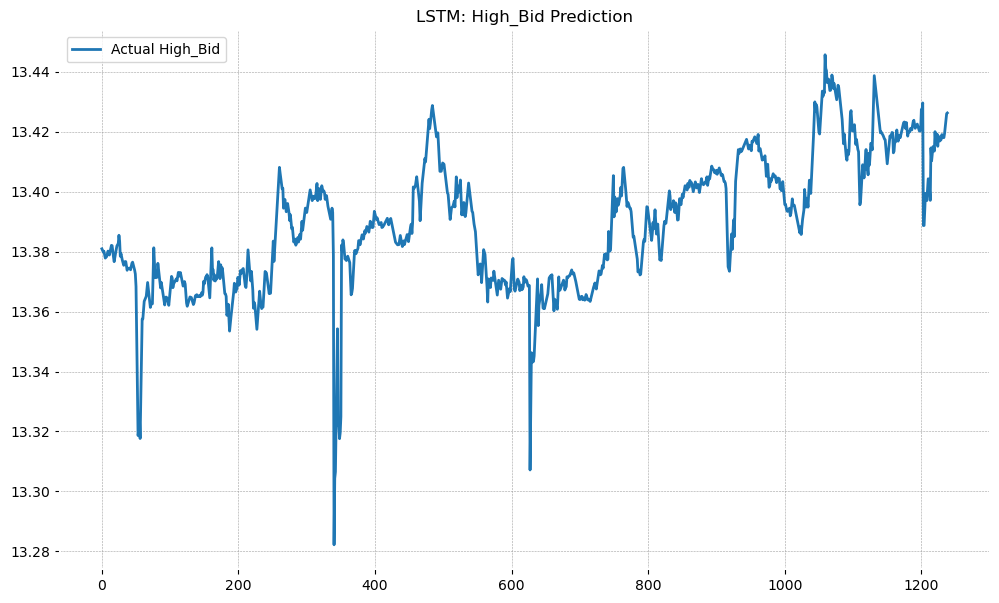

In [60]:
# Plot Additional Graphs
plt.figure(figsize=(12, 7))

plt.plot(y_test[:, 0], label='Actual High_Bid')
#plt.plot(predictions_lstm[:, 0], label='Predicted High_Bid')
plt.title('LSTM: High_Bid Prediction')
plt.legend()
plt.show()

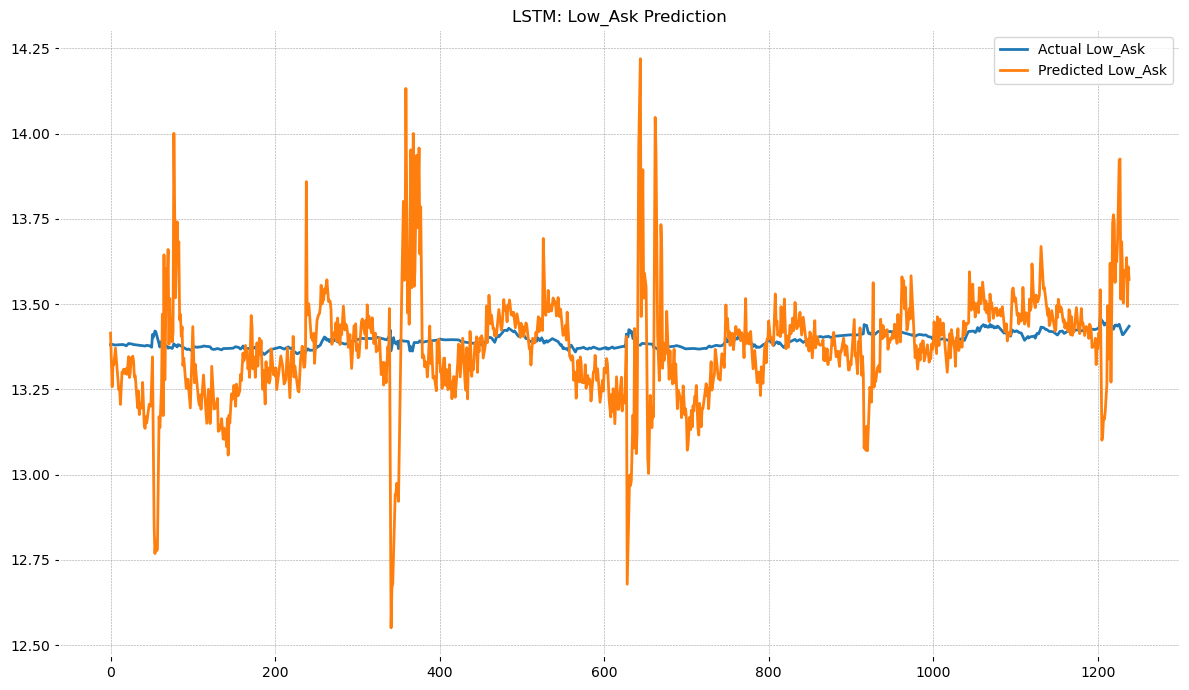

In [61]:
plt.figure(figsize=(12, 7))
plt.plot(y_test[:, 1], label='Actual Low_Ask')
plt.plot(predictions_lstm[:, 1], label='Predicted Low_Ask')
plt.title('LSTM: Low_Ask Prediction')
plt.legend()

plt.tight_layout()
plt.show()
